## Imports and definitions


### Imports

In [280]:
import os
import re
import sys
import glob
import csv
import shutil
from datetime import datetime
from collections import defaultdict

import numpy as np
import numpy.ma as ma
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize

from astropy.io import fits
from astropy.io.fits import getdata
import astropy.units as u
import astropy.constants as const
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord

from scipy.ndimage import rotate, gaussian_filter1d, maximum_filter1d
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import medfilt, find_peaks, detrend
from scipy.special import wofz
from scipy import stats
from scipy.interpolate import CubicSpline

from lmfit.models import VoigtModel, ExponentialModel, SplineModel, LinearModel, GaussianModel, PolynomialModel, ConstantModel
from lmfit import report_fit

import pickle

### Grism Utils v2

In [281]:
import importlib
import grism_utils_v2
importlib.reload(grism_utils_v2)
from grism_utils_v2 import spectrum

### Functions

In [282]:
def _basename(path):
    return os.path.basename(str(path))

def get_obs_time(img_file):
    """
    Return astropy Time object for a FITS file.
    """
    with fits.open(img_file) as hdul:
        hdr = hdul[1].header  # you already use extension 1
        date_obs = hdr.get("DATE-OBS")

        if date_obs is None:
            raise ValueError(f"No DATE-OBS in {img_file}")

    return Time(date_obs, format='isot', scale='utc')

def _spec_file_key(S):
    """Key used to match a restored calibration object to a calibration image file."""
    if hasattr(S, "grism_image") and S.grism_image is not None:
        return _basename(S.grism_image)
    return None

def _build_spec_lookup(calib_spectra):
    """
    Build lookup: basename(grism_image) -> spectrum object
    """
    lookup = {}
    for S in calib_spectra:
        key = _spec_file_key(S)
        if key is not None:
            lookup[key] = S
    return lookup


def _save_calib_list_pickle(objects, filename):

    exclude_attrs = [
        "im",
        "im_rot",
        "subim",
        "cutouts",
    ]

    payload = []

    for obj in objects:
        if obj.flagged:
            continue
        row = {}
        for attr, val in vars(obj).items():
            if attr in exclude_attrs:
                continue

            try:
                pickle.dumps(val)
                row[attr] = val
            except Exception:
                row[attr] = repr(val)

        payload.append(row)

    with open(filename, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def restore_spectrum_objects_from_pickle(pkl_file, spectrum_class):
    """
    Restore lightweight spectrum-like objects from a pickle file
    containing a list of dictionaries.

    Parameters
    ----------
    pkl_file : str
        Path to pickle file.
    spectrum_class : class
        Your spectrum class from grism_utils_v2.py

    Returns
    -------
    objects : list
        List of restored spectrum_class instances.
    """
    with open(pkl_file, "rb") as f:
        data = pickle.load(f)

    objects = []

    for row in data:
        obj = spectrum_class.__new__(spectrum_class)  # bypass __init__

        for key, val in row.items():
            setattr(obj, key, val)

        # Rebuild gain_spline if possible
        # Assumes you saved wave_grid and either gain_smooth or gain
        if hasattr(obj, "wave_grid"):
            if hasattr(obj, "gain_smooth"):
                obj.gain_spline = interp1d(
                    obj.wave_grid,
                    obj.gain_smooth,
                    bounds_error=False,
                    fill_value="extrapolate"
                )
            elif hasattr(obj, "gain"):
                obj.gain_spline = interp1d(
                    obj.wave_grid,
                    obj.gain,
                    bounds_error=False,
                    fill_value="extrapolate"
                )

        objects.append(obj)

    return objects

In [303]:
# ------------------------------------------------------------
# Helper functions for building averaged calibration objects
# ------------------------------------------------------------

def match_science_to_calib(img_files, calib_img_files, tbin=1800, verbose=True):
    """
    Build non-overlapping calibration bins in time, assign each science image
    to the bin containing its nearest calibration image, and keep only bins
    relevant to at least one science image.

    Parameters
    ----------
    img_files : list of str
        Science image filenames.
    calib_img_files : list of str
        Calibration image filenames.
    tbin : float
        Maximum bin width in seconds, measured relative to the first calibration
        image in each bin. Default = 1800 s.
    verbose : bool
        If True, print summary.

    Returns
    -------
    result : dict
        {
            "science_matches": list of dict,
            "calib_bins": list of dict,
            "calib_times": astropy Time array,
            "sorted_calib_files": list of str
        }
    """

    if len(img_files) == 0:
        raise ValueError("img_files is empty.")
    if len(calib_img_files) == 0:
        raise ValueError("calib_img_files is empty.")

    # ----------------------------------------------------------
    # Sort calibration images by time
    # ----------------------------------------------------------
    calib_times = Time([get_obs_time(f).isot for f in calib_img_files], scale="utc")
    calib_pairs = sorted(zip(calib_img_files, calib_times), key=lambda x: x[1].unix)

    sorted_calib_files = [f for f, t in calib_pairs]
    sorted_calib_times = Time([t for f, t in calib_pairs])

    # ----------------------------------------------------------
    # Build non-overlapping bins from calibration images
    # ----------------------------------------------------------
    raw_bins = []
    i = 0
    while i < len(sorted_calib_files):
        ref_file = sorted_calib_files[i]
        ref_time = sorted_calib_times[i]

        bin_files = [ref_file]
        bin_times = [ref_time]
        bin_indices = [i]

        i += 1
        while i < len(sorted_calib_files):
            dt_sec = sorted_calib_times[i].unix - ref_time.unix
            if dt_sec <= tbin:
                bin_files.append(sorted_calib_files[i])
                bin_times.append(sorted_calib_times[i])
                bin_indices.append(i)
                i += 1
            else:
                break

        bin_unix = np.array([t.unix for t in bin_times])
        mid_unix = np.median(bin_unix)
        rep_local_idx = int(np.argmin(np.abs(bin_unix - mid_unix)))

        raw_bins.append({
            "bin_id": len(raw_bins),
            "files": bin_files,
            "times": bin_times,
            "indices": bin_indices,
            "representative_file": bin_files[rep_local_idx],
            "representative_time": bin_times[rep_local_idx],
            "start_time": bin_times[0],
            "end_time": bin_times[-1],
            "n_files": len(bin_files),
        })

    # ----------------------------------------------------------
    # Assign science images to nearest calibration image / bin
    # ----------------------------------------------------------
    science_times = Time([get_obs_time(f).isot for f in img_files], scale="utc")
    science_matches = []

    for sci_file, sci_time in zip(img_files, science_times):
        dt = np.abs((sorted_calib_times - sci_time).to("s").value)
        nearest_idx = int(np.argmin(dt))

        nearest_calib_file = sorted_calib_files[nearest_idx]
        nearest_calib_time = sorted_calib_times[nearest_idx]
        nearest_dt_sec = float(dt[nearest_idx])

        matched_bin = None
        for b in raw_bins:
            if nearest_idx in b["indices"]:
                matched_bin = b
                break

        science_matches.append({
            "science_file": sci_file,
            "science_time": sci_time,
            "nearest_calib_file": nearest_calib_file,
            "nearest_calib_time": nearest_calib_time,
            "nearest_dt_sec": nearest_dt_sec,
            "bin_id": matched_bin["bin_id"],
            "calib_group_files": matched_bin["files"],
            "calib_group_times": matched_bin["times"],
            "representative_file": matched_bin["representative_file"],
            "representative_time": matched_bin["representative_time"],
        })

    # ----------------------------------------------------------
    # Keep only bins actually used by at least one science image
    # ----------------------------------------------------------
    used_bin_ids = sorted(set(row["bin_id"] for row in science_matches))
    used_bins = [raw_bins[bid] for bid in used_bin_ids]

    # remap to consecutive bin ids
    old_to_new = {old: new for new, old in enumerate(used_bin_ids)}

    calib_bins = []
    for b in used_bins:
        b_new = dict(b)
        b_new["bin_id"] = old_to_new[b["bin_id"]]
        calib_bins.append(b_new)

    for row in science_matches:
        old_bin = row["bin_id"]
        row["bin_id"] = old_to_new[old_bin]

    # refresh bin-linked fields in science_matches
    bin_lookup = {b["bin_id"]: b for b in calib_bins}
    for row in science_matches:
        b = bin_lookup[row["bin_id"]]
        row["calib_group_files"] = b["files"]
        row["calib_group_times"] = b["times"]
        row["representative_file"] = b["representative_file"]
        row["representative_time"] = b["representative_time"]

    # ----------------------------------------------------------
    # Verbose summary
    # ----------------------------------------------------------
    if verbose:
        date_start = sorted_calib_times[0].isot if len(sorted_calib_times) > 0 else "N/A"
        date_end = sorted_calib_times[-1].isot if len(sorted_calib_times) > 0 else "N/A"

        print("")
        print("Calibration bin summary")
        print("-----------------------")
        print(f"Found {len(calib_bins)} calibration bins")
        print(f"Calibration date range available: {date_start}  →  {date_end}")
        print(f"Total calibration images available: {len(sorted_calib_files)}")
        print(f"Science images: {len(img_files)}")
        print(f"Bin width criterion: {tbin:.0f} s ({tbin/60:.1f} min)")
        print("")

        # science grouped by bin
        sci_by_bin = {b['bin_id']: [] for b in calib_bins}
        for row in science_matches:
            sci_by_bin[row["bin_id"]].append(os.path.basename(row["science_file"]))

        for b in calib_bins:
            print(
                f"Bin {b['bin_id']:02d}: "
                f"{b['n_files']} calibration file(s), "
                f"{b['start_time'].isot} → {b['end_time'].isot}, "
                f"rep = {os.path.basename(b['representative_file'])}"
            )
            print("  Calibration files:")
            for f, t in zip(b["files"], b["times"]):
                print(f"    - {os.path.basename(f)}  [{t.isot}]")

            print("  Science images:")
            for sci_name in sci_by_bin[b["bin_id"]]:
                print(f"    - {sci_name}")
            print("")

    return {
        "science_matches": science_matches,
        "calib_bins": calib_bins,
        "calib_times": sorted_calib_times,
        "sorted_calib_files": sorted_calib_files,
    }

def _fit_poly_to_curve(x, y, degree):
    """
    Fit polynomial coeffs in np.polyval order (high -> low).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < degree + 1:
        raise ValueError("Not enough valid points to fit polynomial.")
    return np.polyfit(x[good], y[good], degree)

def _average_wavelength_solution(calib_group, npix=None, degree=None):
    """
    Average wavelength solutions from a list of calibration spectrum objects.

    Returns
    -------
    x_common, wave_med, coeff_med
    """
    good = [S for S in calib_group if hasattr(S, "wave_calib") and getattr(S, "wave_calib", None) is not None]
    if len(good) == 0:
        raise ValueError("No calibration objects in group have wave_calib.")

    if npix is None:
        if hasattr(good[0], "imsize_x") and good[0].imsize_x is not None:
            npix = int(good[0].imsize_x)
        else:
            # fallback: infer from common usage
            npix = 4096

    if degree is None:
        degree = len(np.asarray(good[0].wave_calib)) - 1

    x_common = np.arange(npix, dtype=float)

    wave_curves = []
    for S in good:
        c = np.asarray(S.wave_calib, dtype=float)
        wave_curves.append(np.polyval(c, x_common))

    wave_curves = np.array(wave_curves)
    wave_med = np.nanmean(wave_curves, axis=0)

    coeff_med = _fit_poly_to_curve(x_common, wave_med, degree=degree)

    return x_common, wave_med, coeff_med

def _average_gain_solution(calib_group):
    """
    Average gain_smooth arrays from a calibration group on a common wave grid.

    Returns
    -------
    wave_common, gain_med, gain_interp
    """
    good = [
        S for S in calib_group
        if hasattr(S, "wave_grid")
        and hasattr(S, "gain_smooth")
        and (getattr(S, "wave_grid", None) is not None)
        and (getattr(S, "gain_smooth", None) is not None)
    ]
    if len(good) == 0:
        raise ValueError("No calibration objects in group have wave_grid/gain_smooth.")

    wave_mins = [np.nanmin(np.asarray(S.wave_grid, dtype=float)) for S in good]
    wave_maxs = [np.nanmax(np.asarray(S.wave_grid, dtype=float)) for S in good]
    wmin = max(wave_mins)
    wmax = min(wave_maxs)

    if wmin >= wmax:
        raise ValueError("No overlapping wave_grid range in calibration group.")

    n_common = min(len(np.asarray(S.wave_grid)) for S in good)
    wave_common = np.linspace(wmin, wmax, n_common)

    gain_curves = []
    for S in good:
        wave_i = np.asarray(S.wave_grid, dtype=float)
        gain_i = np.asarray(S.gain_smooth, dtype=float)

        valid = np.isfinite(wave_i) & np.isfinite(gain_i)
        wave_i = wave_i[valid]
        gain_i = gain_i[valid]

        if len(wave_i) < 2:
            continue

        order = np.argsort(wave_i)
        wave_i = wave_i[order]
        gain_i = gain_i[order]

        gain_curves.append(np.interp(wave_common, wave_i, gain_i))

    if len(gain_curves) == 0:
        raise ValueError("Could not interpolate any gain curves in calibration group.")

    gain_curves = np.array(gain_curves)
    gain_med = np.nanmean(gain_curves, axis=0)

    gain_interp = interp1d(
        wave_common,
        gain_med,
        bounds_error=False,
        fill_value="extrapolate"
    )

    return wave_common, gain_med, gain_interp

def build_averaged_calib_object(calib_group, spectrum_class, bin_id=None, npix=None, wave_degree=None):
    """
    Build a lightweight spectrum-like calibration object from a calibration group.
    Compatible with downstream code expecting .wave_calib, .gain_spline, etc.
    """
    if len(calib_group) == 0:
        raise ValueError("calib_group is empty.")

    template = calib_group[0]

    x_common, wave_med, coeff_med = _average_wavelength_solution(
        calib_group,
        npix=npix,
        degree=wave_degree
    )

    wave_common, gain_med, gain_interp = _average_gain_solution(calib_group)

    avg = spectrum_class.__new__(spectrum_class)

    # copy a few metadata attrs from template if present
    for attr in ["filter", "camera", "hdr"]:
        if hasattr(template, attr):
            setattr(avg, attr, getattr(template, attr))

    avg.object_name = f"AVG_CALIB_BIN_{bin_id}" if bin_id is not None else "AVG_CALIB"
    avg.grism_image = None
    avg.obs_date = None
    avg.flagged = False

    # wavelength-calibration attrs
    avg.wave_calib = coeff_med
    avg.wave_r2 = None
    avg.imsize_x = len(x_common)
    avg.wave_curve_avg = wave_med

    # gain-calibration attrs
    avg.wave_grid = wave_common
    avg.gain_smooth = gain_med
    avg.gain = gain_med.copy()
    avg.gain_spline = gain_interp

    # bookkeeping
    avg.bin_id = bin_id
    avg.calib_group_members = [getattr(S, "grism_image", None) for S in calib_group]

    return avg

# ------------------------------------------------------------
# Missing-calibration derivation
# ------------------------------------------------------------

def derive_single_calib_spectrum(grism_image, spectrum_class, filter):
    """
    Derive one calibration spectrum object from a calibration image.
    """
    S = spectrum_class(grism_image, calib_spectrum=None, filter=filter, calib_img=True)

    # Same core workflow you were already using
    trace_center, cutouts, subim = S.fit_trace(plot=False, curved=True)
    spec = S.extract_spectrum(
        show_box=False,
        plot=False,
        curved_box=True,
    )
    telluric_pixel = S.fit_telluric(plot=False)
    wavelength_correction = S.derive_wavelength_correction()
    wave_calib = S.derive_wavelength_solution(show_points=False, plot=False)
    waves = S.wavelength_calibrate()
    ref_wave, ref_flux = S.load_stelib_spectrum('STELIB')
    wave_grid, flux_data_interp, flux_ref_interp = S.match_and_interpolate()
    gain_curve = S.derive_gain_calibration(plot=False)

    return S

def ensure_required_calib_spectra(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class,
    filter,
    save_updated=True,
    zwo_pkl=None,
    qhy_pkl=None,
    verbose=True
):
    """
    Ensure every calibration image referenced in matches exists as a calibration object.
    Derive missing ones, append to correct camera list, and optionally save updated pickles.
    """
    zwo_lookup = _build_spec_lookup(ZWO_calib_spectra)
    qhy_lookup = _build_spec_lookup(QHY_calib_spectra)

    needed_calib_files = sorted({
        _basename(f)
        for row in matches["science_matches"]
        for f in row["calib_group_files"]
    })

    # Need full paths, not just basenames
    needed_fullpaths = {}
    for row in matches["science_matches"]:
        for f in row["calib_group_files"]:
            needed_fullpaths[_basename(f)] = f

    new_zwo = []
    new_qhy = []

    for key in needed_calib_files:
        if key in zwo_lookup or key in qhy_lookup:
            continue

        fullpath = needed_fullpaths[key]
        if verbose:
            print(f"Deriving missing calibration spectrum: {key}")

        try:
            S = derive_single_calib_spectrum(fullpath, spectrum_class, filter)

            cam = getattr(S, "camera", None)
            if cam == "ASI Camer":
                ZWO_calib_spectra.append(S)
                new_zwo.append(key)
                zwo_lookup[key] = S
            elif cam == "QHYCCD-Ca":
                QHY_calib_spectra.append(S)
                new_qhy.append(key)
                qhy_lookup[key] = S
            else:
                # fallback: put into ZWO list if camera is missing/unknown
                ZWO_calib_spectra.append(S)
                new_zwo.append(key)
                zwo_lookup[key] = S
                if verbose:
                    print(f"  Warning: unknown camera '{cam}' for {key}; appended to ZWO list.")

        except Exception as e:
            if verbose:
                print(f"  Failed to derive {key}: {e}")

    if save_updated:
        if zwo_pkl is None:
            zwo_pkl = f"Calib_Spectra_{filter}_ZWO.pkl"
        if qhy_pkl is None:
            qhy_pkl = f"Calib_Spectra_{filter}_QHY.pkl"

        _save_calib_list_pickle(ZWO_calib_spectra, zwo_pkl)
        _save_calib_list_pickle(QHY_calib_spectra, qhy_pkl)

        if verbose:
            print("")
            print(f"Saved updated ZWO calibration list -> {zwo_pkl}")
            print(f"Saved updated QHY calibration list -> {qhy_pkl}")

    return {
        "ZWO_calib_spectra": ZWO_calib_spectra,
        "QHY_calib_spectra": QHY_calib_spectra,
        "new_zwo_files": new_zwo,
        "new_qhy_files": new_qhy,
    }

# ------------------------------------------------------------
# Build averaged per-bin calibration objects
# ------------------------------------------------------------

def build_bin_averaged_calibrations(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class,
    derivation_summary=None,
    verbose=True
):
    """
    Build one averaged calibration object per calibration bin.

    Parameters
    ----------
    derivation_summary : dict or None
        Optional summary from ensure_required_calib_spectra(), e.g.
        {
            "new_zwo_files": [...],
            "new_qhy_files": [...]
        }
    """
    zwo_lookup = _build_spec_lookup(ZWO_calib_spectra)
    qhy_lookup = _build_spec_lookup(QHY_calib_spectra)

    bin_avg_lookup = {}
    failed_bins = []

    for bin_info in matches["calib_bins"]:
        bin_id = bin_info["bin_id"]
        group_files = bin_info["files"]

        calib_group = []
        for f in group_files:
            key = _basename(f)
            if key in zwo_lookup:
                calib_group.append(zwo_lookup[key])
            elif key in qhy_lookup:
                calib_group.append(qhy_lookup[key])

        if len(calib_group) == 0:
            failed_bins.append(bin_id)
            continue

        try:
            avg_obj = build_averaged_calib_object(
                calib_group,
                spectrum_class=spectrum_class,
                bin_id=bin_id
            )
            bin_avg_lookup[bin_id] = avg_obj
        except Exception:
            failed_bins.append(bin_id)

    if verbose:
        n_bins_total = len(matches["calib_bins"])
        n_bins_built = len(bin_avg_lookup)
        n_bins_failed = len(failed_bins)

        n_new_zwo = 0
        n_new_qhy = 0
        n_new_total = 0

        if derivation_summary is not None:
            n_new_zwo = len(derivation_summary.get("new_zwo_files", []))
            n_new_qhy = len(derivation_summary.get("new_qhy_files", []))
            n_new_total = n_new_zwo + n_new_qhy

        print("")
        print("Averaged calibration summary")
        print("----------------------------")
        print(f"Science-relevant calibration bins found: {n_bins_total}")
        print(f"Averaged calibration objects built:      {n_bins_built}")
        print(f"Bins that failed to build:               {n_bins_failed}")
        print(f"Calibration images newly derived:        {n_new_total}")
        print(f"  ZWO appended:                          {n_new_zwo}")
        print(f"  QHY appended:                          {n_new_qhy}")

        if n_bins_failed > 0:
            print(f"Failed bin IDs: {failed_bins}")

    return bin_avg_lookup

# ------------------------------------------------------------
# Assign averaged calibrations to science images
# ------------------------------------------------------------

def attach_bin_averaged_calibrations_to_science_matches(matches, bin_avg_lookup):
    """
    Add an averaged calibration object to each science match row.
    """
    for row in matches["science_matches"]:
        row["averaged_calib_spectrum"] = bin_avg_lookup.get(row["bin_id"], None)
    return matches

## LRG or HRG? (Make sure to select desired option)

In [268]:
# filter = 'hrg'
filter = 'lrg'

## Load Science + Calibration Data

In [297]:
# Please paste in your own directories here for saving output files
out_folder = os.path.expanduser('~/Desktop/Code/')
drive_path = os.path.expanduser('~/gdrive/Shared Drives/MACRO-Be/resources/Data') #Comment this out if you do not have drive mounted

#Specify a basepath
# basepath = os.path.expanduser('~/Desktop/Code/reduced_data/')
basepath = os.path.expanduser('~/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/')

# /Users/research/Desktop/RLMT/2026-01-21

## Priority Targets
# target = 'V442_And'
# target = '69_Ori'
# target = 'Lam_Eri'

## Primary Targets
# target = 'V742_Cas'
# target = ['Gamma_Cas', 'Gam_Cas']
# target = 'phi_and'
# target = 'Phi_Per'
# target = 'Psi_Per'
# target = 'CT_Cam'
# target = 'V1369_Ori'
# target = ['Zeta_Tau', 'Zet_Tau']
# target = 'AX_Mon'
# target = 'QQ_Gem'
# target = 'Bet_Cmi'
# target = 'RY_Sct'
# target = 'HD_44637'
# target = 'pi_Aqr'

## Oe Stars
# target = ['BD+59_553', 'HD_17520']
# target = 'x_per'
# target = ['PZ_Gem', 'HD_45314']
# target = ['BN_Gem', 'HD_60848']
# target = '68_Cyg'

## Survey Targets
# target = 'Alcyone'
# target = 'HD_23800'
# target = 'V586_Per'
# target = '56_Eri'
# target = '2_Ori'
# target = '105_Tau'
# target = '12_Aur'
# target = 'HD_49787'
# target = 'HD_53416'
# target = '5_Cnc'
# target = 'kap_Dra'
# target = 'tet_CrB'
# target = '51_Oph'
# target = 'V3903_Sgr'
# target = 'HD_179343'
# target = 'HD_189689'
# target = 'HD_201522'
# target = 'ups_cyg'
# target = 'V2162_Cyg'
# target = '25_Peg'
# target = 'HD_216057'
# target = '14_Lac'

## Calibration Targets
# target = 'HR_718'
# target = 'HR_4468'
# target = 'HR_3454'
# target = 'HR_4963

## Spring Targets
# target = 'bet_mon_A'
# target = 'HD_50658'
# target = 'phi_Leo'
# target = 'V763_Mon'
# target = 'HIP_49583' # eta Leonis / HD87737
# target = 'HD_50658'
# target = '*' # Select this if no specific target
# target = 'PLEIONE'
# target = '11_Cam'
# target = 'CQ_UMa'
# target = 'phi_and'
# target = 't_crb'
# target = 'rho_oph_c'
# target = 'G191-B2B'
# target = 'BT_CMi'

## Other
# target = 'EV_Lac'
# target = 'AD_Leo'
# target = 'BU_Tau'
# target = 'HD_36958'
# target = 'HD_37061'
# target = 'HD_37058'
# target = 'SN_1971G'
# target = 'Spica'
# target = 'bet_per'
# target = 'SN_2026acd'
# target = 'V2304_Oph'
# target = '2MASS_J16255459-2330291'
# target = '2_Vul'
target = 'V444_Cyg'

## PHYS440 Targets
# target = 'HD_23753'
# target = 'HD_9823'
# target = 'Feige_80'
# target = 'HD_21427'
# target = 'HD_122064'
# target = 'Pi1_Ursae_Majoris'
# target = 'Rho_Geminorum'
# target = 'Upsilon_Orionis'
# target = '2_Camelopardalis'
# target = 'BD-03_2870'
# target = 'HD_8671'
# target = '16_Lib'
# target = 'NGC_4151'
# target = 'NGC_4388'
# target = 'NGC_4395'
# target = 'SZ_Uma'
# target = 'HD_75632B'

calib_targets = ['hr_718', 'hr_3454', 'hr_4468', 'hr_4963']
# calib_targets = ['hr_718', 'hr_3454']
# calib_targets = ['hr_3454']

# ----- FLEXIBLE HANDLING -----
if isinstance(target, str):
    targets = [target]
else:
    targets = list(target)

# Build regex to match any target alias safely
target_pattern = re.compile(
    r"(?<![A-Za-z0-9])(" + "|".join(re.escape(t) for t in targets) + r")(?![A-Za-z0-9])",
    re.IGNORECASE
)

calib_target_pattern = re.compile(
    r"(?<![A-Za-z0-9])(" + "|".join(re.escape(t) for t in calib_targets) + r")(?![A-Za-z0-9])",
    re.IGNORECASE
)

# Create image and calibration file lists

img_files = []
calib_img_files = []

if filter =='hrg':
    patterns = [
        f"{basepath}/2025*/*hrg*.fz",
        f"{basepath}/2026*/*hrg*.fz"  # broad pattern
    ]
elif filter == 'lrg':
    patterns = [
        f"{basepath}/2025*/*lrg*.fz",
        f"{basepath}/2026*/*lrg*.fz"  # broad pattern
    ]

for pattern in patterns:
    for m in glob.glob(pattern):
        base = os.path.basename(m)
        if re.search(target_pattern, base):
            img_files.append(m)

img_files = sorted(img_files)
n_img_files = len(img_files)

for pattern in patterns:
    for m in glob.glob(pattern):
        base = os.path.basename(m)
        if re.search(calib_target_pattern, base):
            calib_img_files.append(m)

calib_img_files = sorted(calib_img_files)
n_calib_files = len(calib_img_files)

print('')
print(f'Found {n_img_files} science images')
print(f'Found {n_calib_files} calibration images')
print('')


Found 3 science images
Found 301 calibration images



In [298]:
# Filter by centering
centered_list = []

for i in range(len(img_files)):
    hdu = fits.open(img_files[i])
    hdul = hdu[1].header
    centered = hdul["CENTERED"]
    if centered == False:
        try:
            winstabl = hdul["WINSTABL"]
            centered_list.append(winstabl)
        except: 
            centered_list.append(centered)
    else:
        centered_list.append(centered)

i = 0
while i < len(centered_list):
  if centered_list[i] == False:
    # print(f'Not centered, deleting image: {img_files[i]}')
    del img_files[i]
    del centered_list[i]
    continue
  else:
    i += 1

calib_centered_list = []

for i in range(len(calib_img_files)):
    hdu = fits.open(calib_img_files[i])
    hdul = hdu[1].header
    centered = hdul["CENTERED"]
    if centered == False:
        try:
            winstabl = hdul["WINSTABL"]
            calib_centered_list.append(winstabl)
        except: 
            calib_centered_list.append(centered)
    else:
        calib_centered_list.append(centered)

# for i in range(len(img_files)):
#   print(img_files[i], f'Centering = {centered_list[i]}')

i = 0
while i < len(calib_centered_list):
  if calib_centered_list[i] == False:
    # print(f'Not centered, deleting image: {img_files[i]}')
    del calib_img_files[i]
    del calib_centered_list[i]
    continue
  else:
    i += 1

#Print the result
print(f"{len(img_files)} of {n_img_files} science images are centered")
print(f"{len(calib_img_files)} of {n_calib_files} calibration images are centered")

3 of 3 science images are centered
294 of 301 calibration images are centered


In [299]:
# # Time sorting optimization for calibration images

# science_times = Time([get_obs_time(f).isot for f in img_files], scale='utc')
# calib_times   = Time([get_obs_time(f).isot for f in calib_img_files], scale='utc')

# # Track which calibration files are actually used
# used_calibs = set()

# for sci_file, sci_time in zip(img_files, science_times):
#     # Time differences in seconds
#     dt = np.abs((calib_times - sci_time).to('s').value)

#     idx = np.argmin(dt)
#     used_calibs.add(calib_img_files[idx])

#     print(f"{os.path.basename(sci_file)} → "
#           f"{os.path.basename(calib_img_files[idx])} "
#           f"({dt[idx]/60:.1f} min)")
    
# filtered_calib_img_files = sorted(used_calibs)
# filtered_calib_times  = Time([get_obs_time(f).isot for f in filtered_calib_img_files], scale='utc')

# print('')
# print(f"Kept {len(filtered_calib_img_files)} out of {len(calib_times)} calibration files")

## (Optional) Display Images + Statistics

/Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-03-27/jos_V444_Cyg_lrg_180s_2026-03-27T11-03-06_calibrated.fts.fz


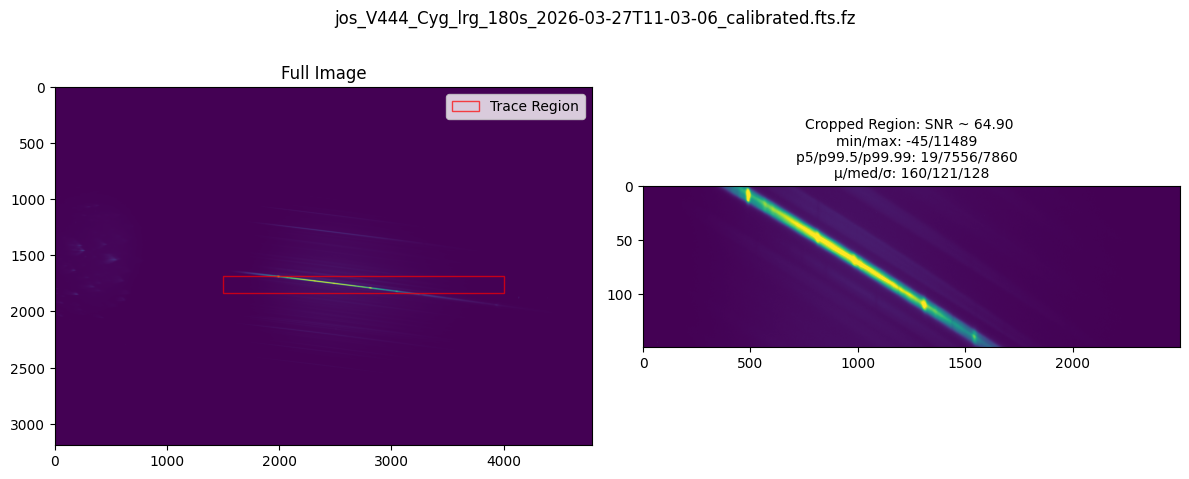

In [272]:
from matplotlib.patches import Rectangle
from astropy.stats import sigma_clipped_stats

i_start = 0
i_end = 1 # First i_end - 1 images
# i_end = len(img_files) # All images

for grism_image in img_files[i_start:i_end]:

    if filter == 'hrg':
        xstart = 500
        ystart = 1580
        xwidth = 4200
        ywidth = 200
    
    if filter == 'lrg':
        xstart = 1500
        ystart = 1760
        xwidth = 2500
        ywidth = 150

    print(grism_image)

    image_data = fits.getdata(grism_image)

    ymin = ystart - int(ywidth/2)
    ymax = ystart + int(ywidth/2)

    # Crop region
    cropped_image_data = image_data[
        ymin: ymax,
        xstart : xstart + xwidth
    ]

    # --- Statistics ONLY on cropped region ---
    mean_sc, med_sc, std_sc = sigma_clipped_stats(
        cropped_image_data, sigma=3.0, maxiters=5
    )

    vmin_p, vmax_p = np.percentile(cropped_image_data, (5, 99.5))
    p9999 = np.percentile(image_data, 99.99)
    dmin = float(np.nanmin(cropped_image_data))
    dmax = float(np.nanmax(cropped_image_data))

    # --- Create figure with two panels ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -------- Left: full image --------
    ax_full = axes[0]
    ax_full.imshow(
        image_data,
        cmap="viridis",
        vmin=vmin_p,
        vmax=vmax_p
    )
    ax_full.set_title("Full Image")

    rect = Rectangle(
        (xstart, ymin),
        xwidth,
        ywidth,
        facecolor='none',
        edgecolor='red',
        alpha=0.7,
        label='Trace Region'
    )
    ax_full.add_patch(rect)
    ax_full.legend()

    # -------- Right: cropped image --------
    ax_crop = axes[1]
    ax_crop.imshow(
        cropped_image_data,
        cmap="viridis",
        vmin=vmin_p,
        vmax=vmax_p
    )

    # Stats shown as the title (no overlap possible)
    stats_title = (
        f"Cropped Region: SNR ~ {p9999 / med_sc:.2f} \n"
        f"min/max: {dmin:.0f}/{dmax:.0f}  \n"
        f"p5/p99.5/p99.99: {vmin_p:.0f}/{vmax_p:.0f}/{p9999:.0f}  \n"
        f"μ/med/σ: {mean_sc:.0f}/{med_sc:.0f}/{std_sc:.0f}"
    )
    ax_crop.set_title(stats_title, fontsize=10)
    ax_crop.set_aspect(5)

    # Figure title
    fig.suptitle(grism_image.split("/")[-1])

    plt.tight_layout()
    plt.show()

## Calculate Radial Velocity Wavelength Corrections

In [273]:
# Query Simbad for the recessional velocity of the target

!pip3 install astroquery

from astroquery.simbad import Simbad

# Reset to default fields
Simbad.reset_votable_fields()

# List available votable fields
print("Available votable fields:")
print(Simbad.list_votable_fields())

Simbad.add_votable_fields('rvz_radvel')

star_name = targets[0]
result_table = Simbad.query_object(star_name)

if result_table is None:
    print(f"No results found for {star_name}.")
else:
    print("Returned columns:", result_table.colnames)

    if 'rvz_radvel' in result_table.colnames:
        rv = result_table['rvz_radvel'][0]
        if rv is None:
            print('')
            print(f"No radial (recessional) velocity available for {star_name}.")
            print('')
        else:
            print('')
            print(f"The radial (recessional) velocity of {star_name} is {rv} km/s.")
            print('')
    else:
        print("Radial velocity column not found in the result. Available columns are:")
        print(result_table.colnames)

Available votable fields:
    name    ...     type   
----------- ... -----------
mesDiameter ...       table
      mesPM ...       table
     mesISO ...       table
     mesSpT ...       table
  allfluxes ...       table
      ident ...       table
       flux ...       table
   mesOtype ...       table
     mesPLX ...       table
   otypedef ...       table
        ... ...         ...
          K ... filter name
          u ... filter name
          g ... filter name
          r ... filter name
          i ... filter name
          z ... filter name
          G ... filter name
      F150W ... filter name
      F200W ... filter name
      F444W ... filter name
Length = 116 rows
Returned columns: ['main_id', 'ra', 'dec', 'coo_err_maj', 'coo_err_min', 'coo_err_angle', 'coo_wavelength', 'coo_bibcode', 'rvz_radvel', 'matched_id']

The radial (recessional) velocity of V444_Cyg is 3.0 km/s.



In [274]:
# Calculate earth + target recessional velocity corrections with astropy for rigel based on DATE-OBS in header

target_velocity = rv*u.km/u.s
radial_velocities = []
wavelength_corrections = []
times = []

target_name = targets[0].replace('_', ' ')

for i in range(len(img_files)):
  # Get the DATE-OBS from the header
  hdu = fits.open(img_files[i])
  hdul = hdu[1].header
  date_obs = hdul['DATE-OBS']
  # print(date_obs)

  # Should really pull the target from the header...
  target_star = SkyCoord.from_name(target_name)
  # print(target)

  # Get the observatory location
  obs_loc = EarthLocation.of_site('Winer')
  # print(obs_loc)

  # Convert date_obs to astropy time
  t = Time(date_obs, format='isot', scale='utc', location=obs_loc)
  times.append(t)
  # print(t)

  radial_vel_correction = target_star.radial_velocity_correction(obstime=t).to('km/s')
  # print("Earth motion velocity: ", radial_vel_correction)
  # print("Target velocity: ", target_velocity)

  c = 299792.458 * u.km/u.s  # Speed of light in km/s
  wavelength_correction = 1 + (radial_vel_correction + target_velocity) / c
  # print("Total Radial Velocity", radial_vel_correction + target_velocity)
  # print("Wavelength correction: ", wavelength_correction)

  radial_velocities.append(radial_vel_correction + target_velocity)
  wavelength_corrections.append(wavelength_correction)

for i in range(len(radial_velocities)):
  print(f'Date and Time of Observation: {times[i]}')
  print(f'Radial Velocity Correction: {radial_velocities[i]}')
  print(f'Wavelength Correction: {wavelength_corrections[i]}')
  if wavelength_corrections[i] < 1:
    print('Light is blue shifted')
  else:
    print('Light is red shifted')
  print('')

Date and Time of Observation: 2026-03-27T11:05:29.270
Radial Velocity Correction: 14.614743226999554 km / s
Wavelength Correction: 1.0000487495360106
Light is red shifted

Date and Time of Observation: 2026-03-27T11:08:33.020
Radial Velocity Correction: 14.613374505966853 km / s
Wavelength Correction: 1.0000487449704487
Light is red shifted

Date and Time of Observation: 2026-04-09T12:13:23.080
Radial Velocity Correction: 16.903595899493325 km / s
Wavelength Correction: 1.000056384326718
Light is red shifted



## Import and Update Calibration Solutions

In [300]:
# Import existing calibration spectra class objects from pickles

ZWO_calib_spectra = restore_spectrum_objects_from_pickle(
    f"Calib_Spectra_{filter}_ZWO.pkl",
    spectrum
)

QHY_calib_spectra = restore_spectrum_objects_from_pickle(
    f"Calib_Spectra_{filter}_QHY.pkl",
    spectrum
)

In [301]:
# Bin calibration spectra and match to science images
matches = match_science_to_calib(
    img_files,
    calib_img_files,
    tbin=1800,
    verbose=True # set verbose=False to suppress summary printout
) 


Calibration bin summary
-----------------------
Found 2 calibration bins
Calibration date range available: 2025-12-18T04:04:21.820  →  2026-04-18T09:31:19.660
Total calibration images available: 294
Science images: 3
Bin width criterion: 1800 s (30.0 min)

Bin 00: 2 calibration file(s), 2026-03-27T10:43:59.840 → 2026-03-27T10:45:33.270, rep = jos_HR_4963_lrg_15s_2026-03-27T10-39-55_calibrated.fts.fz
  Calibration files:
    - jos_HR_4963_lrg_15s_2026-03-27T10-39-55_calibrated.fts.fz  [2026-03-27T10:43:59.840]
    - jos_HR_4963_lrg_15s_2026-03-27T10-41-24_calibrated.fts.fz  [2026-03-27T10:45:33.270]
  Science images:
    - jos_V444_Cyg_lrg_180s_2026-03-27T11-03-06_calibrated.fts.fz
    - jos_V444_Cyg_lrg_180s_2026-03-27T11-06-13_calibrated.fts.fz

Bin 01: 6 calibration file(s), 2026-04-09T04:05:38.560 → 2026-04-09T04:29:43.640, rep = jos_HR_4468_lrg_15s_2026-04-09T04-28-17_calibrated.fts.fz
  Calibration files:
    - jos_HR_3454_lrg_15s_2026-04-09T04-04-52_calibrated.fts.fz  [2026-04-0

In [304]:
# 1) Derive any missing calibration spectra and update the stored lists
update_result = ensure_required_calib_spectra(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class=spectrum,
    filter=filter,
    save_updated=True,
    zwo_pkl=f"Calib_Spectra_{filter}_ZWO.pkl",
    qhy_pkl=f"Calib_Spectra_{filter}_QHY.pkl",
    verbose=True
)

ZWO_calib_spectra = update_result["ZWO_calib_spectra"]
QHY_calib_spectra = update_result["QHY_calib_spectra"]

# 2) Build one averaged calibration object per bin (mean averaging of wavelength and gain solutions in each bin)
bin_avg_lookup = build_bin_averaged_calibrations(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class=spectrum,
    verbose=True
)

# 3) Attach the averaged calibration objects to each science-image match row
matches = attach_bin_averaged_calibrations_to_science_matches(
    matches,
    bin_avg_lookup
)


Saved updated ZWO calibration list -> Calib_Spectra_lrg_ZWO.pkl
Saved updated QHY calibration list -> Calib_Spectra_lrg_QHY.pkl

Averaged calibration summary
----------------------------
Science-relevant calibration bins found: 2
Averaged calibration objects built:      2
Bins that failed to build:               0
Calibration images newly derived:        0
  ZWO appended:                          0
  QHY appended:                          0


## Extract + Calibrate Science Spectra

In [ ]:
spectra = []

science_matches = matches["science_matches"]

for i, row in enumerate(science_matches):
    grism_image = row["science_file"]
    match = row.get("averaged_calib_spectrum", None)

    try:
        if match is None:
            raise ValueError("No averaged calibration spectrum assigned.")

        S = spectrum(grism_image, calib_spectrum=match, filter=filter)

        print('')
        print(f'Processing image {i + 1} of {len(science_matches)}: {S.object_name} {S.obs_date} ({S.exp_time} s):')
        print('')

        trace_center, cutouts, subim = S.fit_trace(plot=False, curved=True)
        spec = S.extract_spectrum(
            show_box=False,
            plot=False,
            curved_box=True
        )
        telluric_pixel = S.fit_telluric(plot=False)
        waves = S.wavelength_calibrate(plot=False)
        cal_spec = S.gain_calibrate(plot=False)

        spectra.append(S)

    except Exception as e:
        print(f"Failed on {os.path.basename(grism_image)}: {e}")
        try:
            S.flagged = True
            spectra.append(S)
        except:
            pass
        continue


Processing image 1 of 3: V444 Cyg 2026-03-27 11:05:29.27 (180.0 s):


Processing image 2 of 3: V444 Cyg 2026-03-27 11:08:33.02 (180.0 s):


Processing image 3 of 3: V444 Cyg 2026-04-09 12:13:23.08 (120.0 s):



# How does calibration work?

Single cell iteration example of deriving calibration solutions and applying them to a science spectrum

QHYCCD-Cameras-Capture
Moon Angle & Phase: 105.70 degrees, 39.55 %


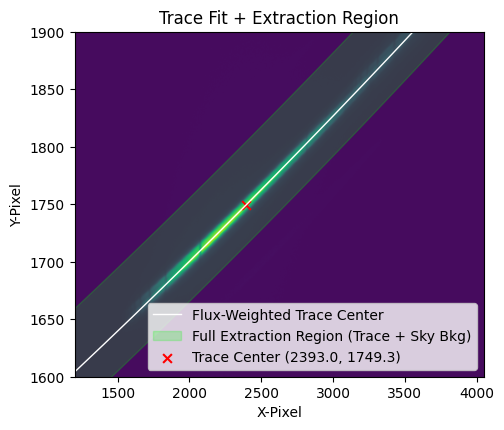

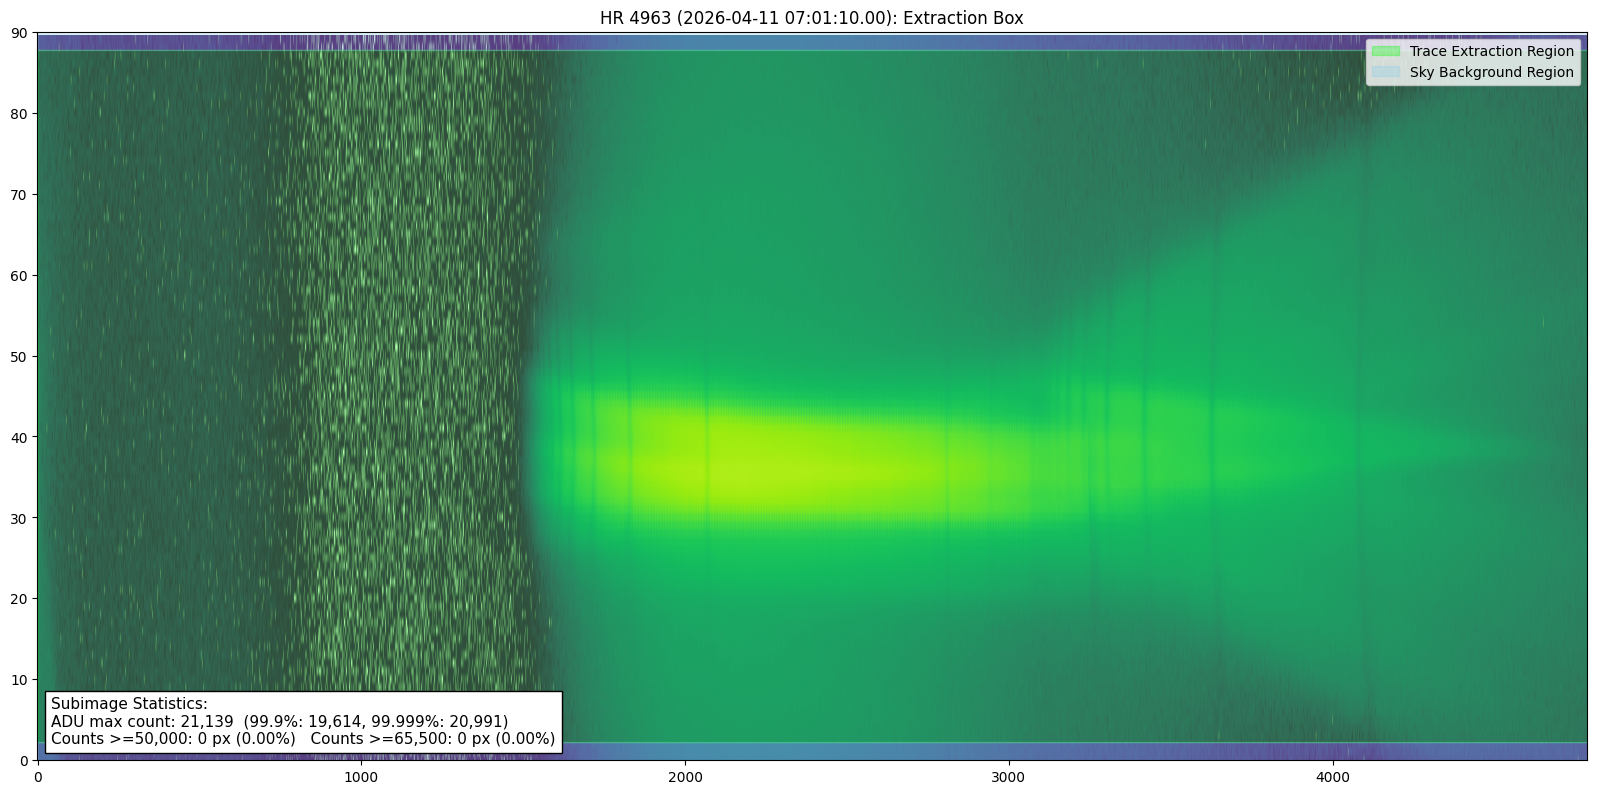

/Users/joshuamarine/Desktop/Code/grism_utils_v2.py:588: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


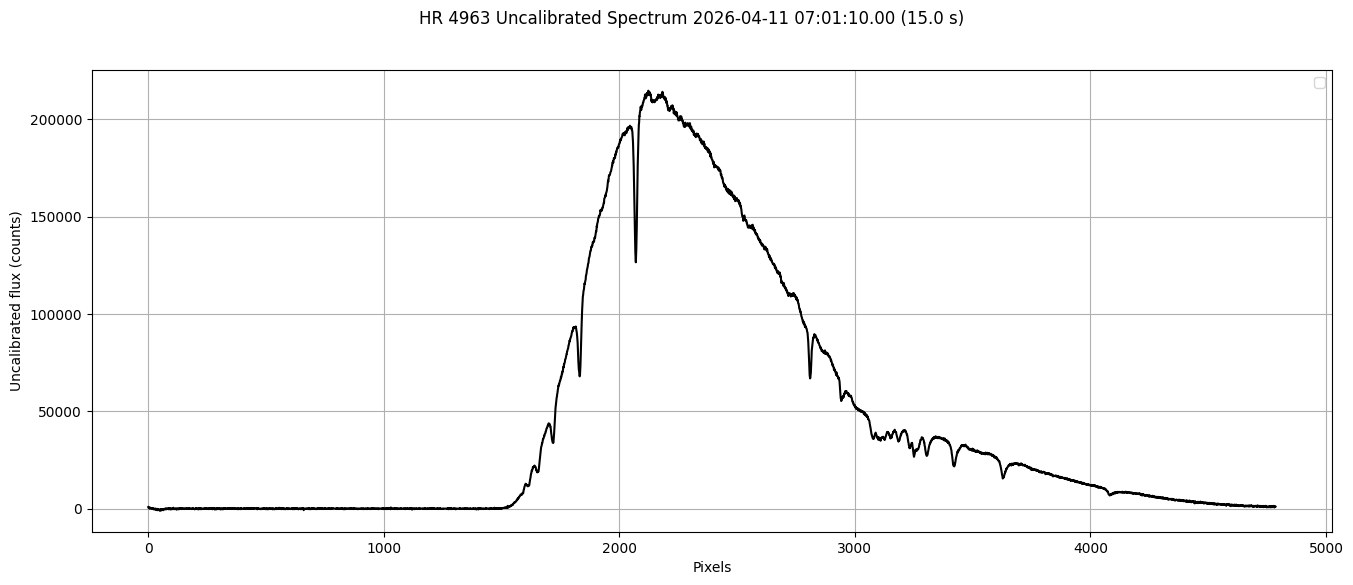

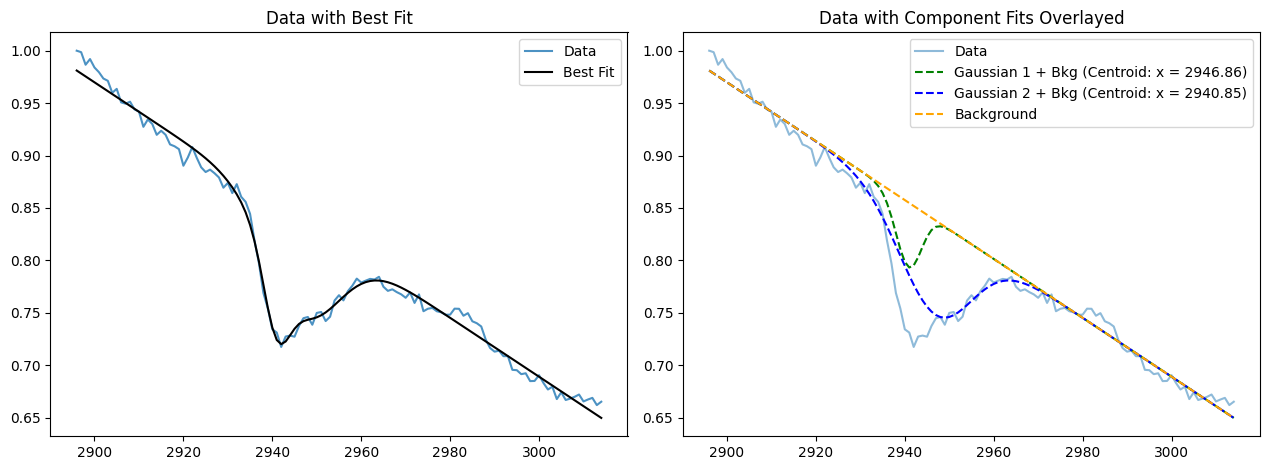

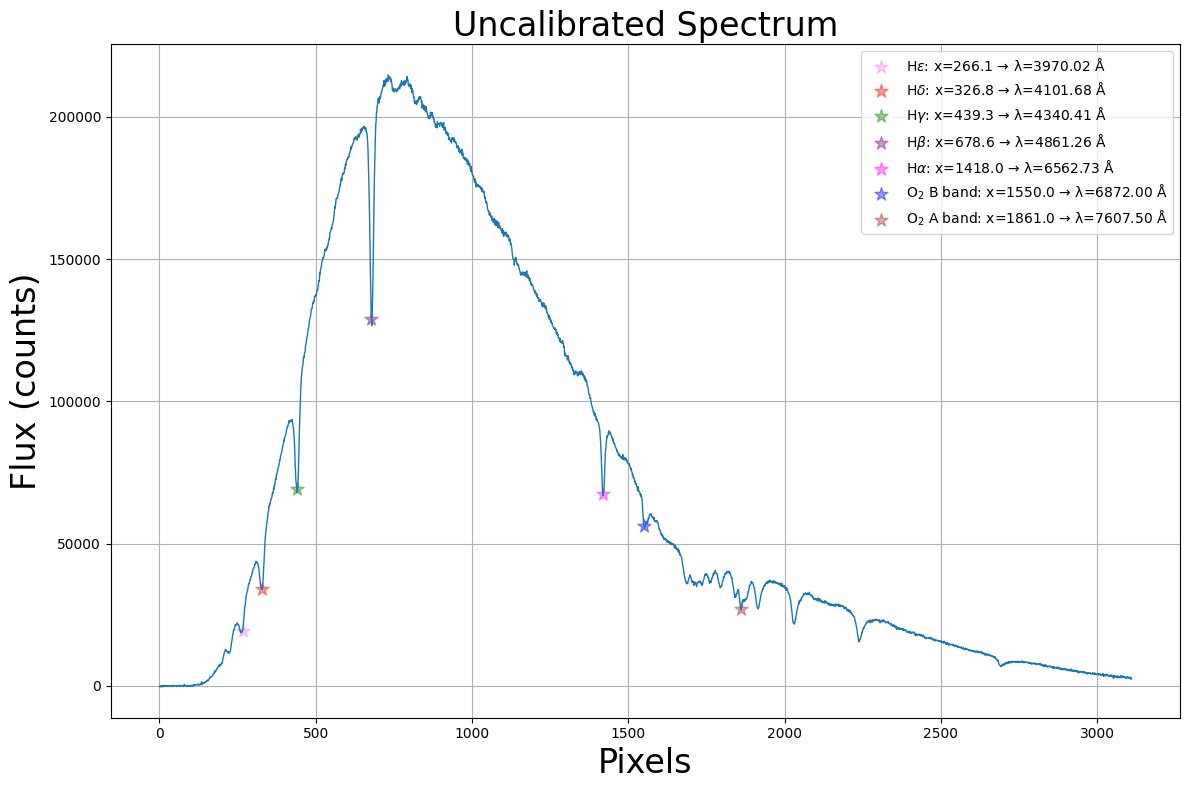

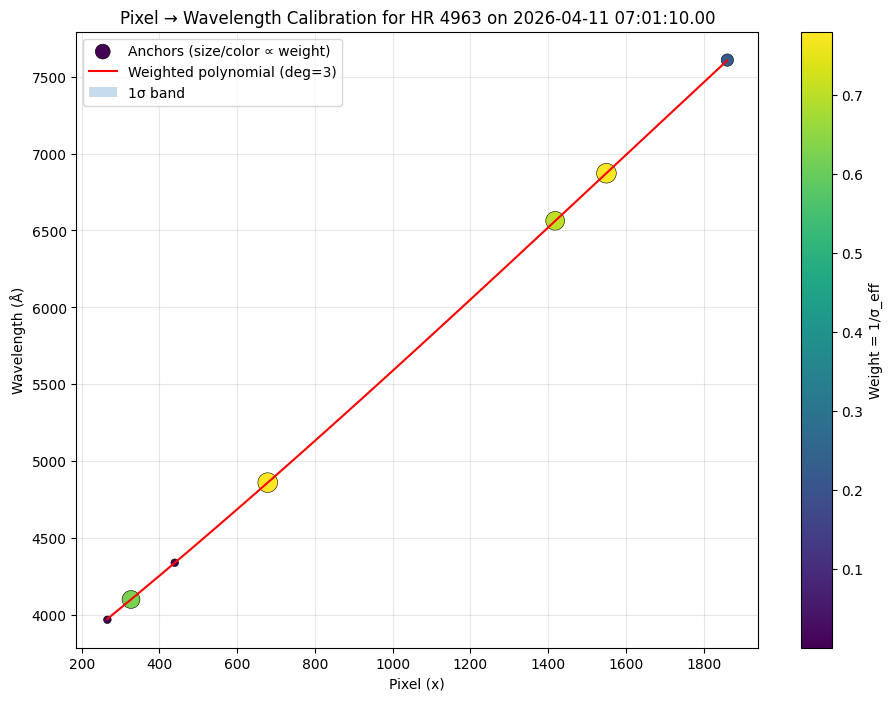

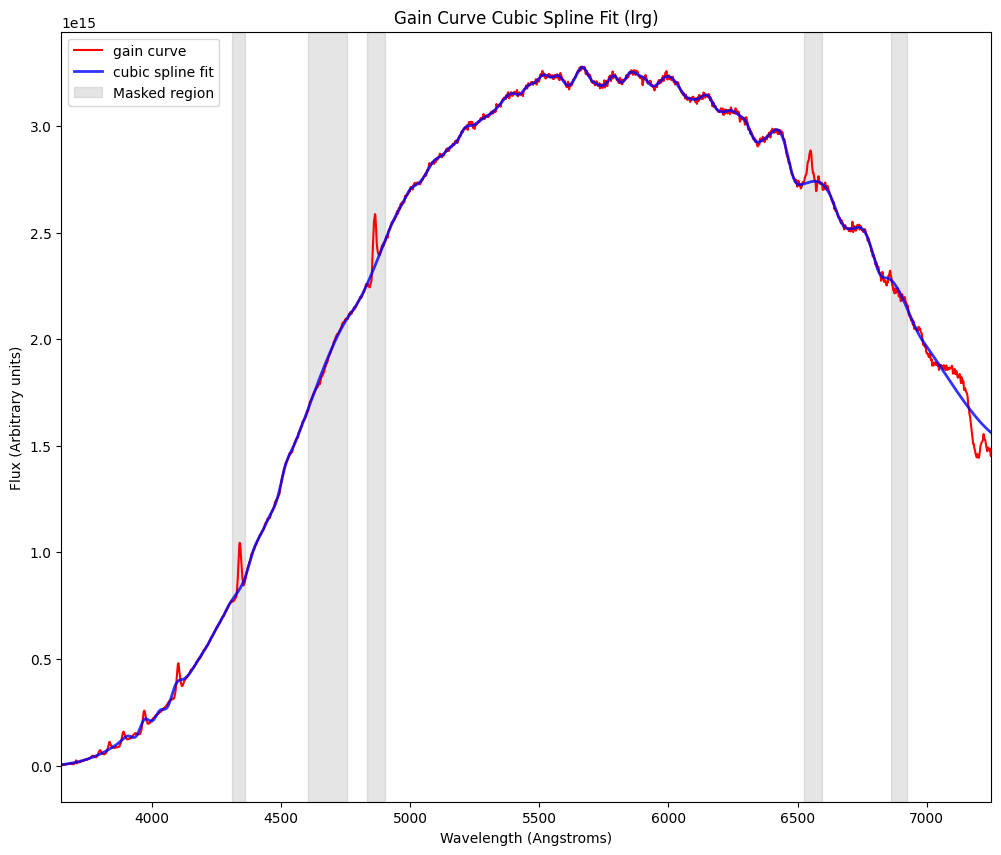

In [321]:
# Demonstrative calibration derivation example

i = 200

S = spectrum(calib_img_files[i], calib_spectrum = None, filter = filter, calib_img = True)

print(S.hdr['INSTRUME'])
print(f'Moon Angle & Phase: {S.moonangle:.2f} degrees, {(S.moonphase * 100):.2f} %')

trace_center, cutouts, subim = S.fit_trace(plot = True, curved = True)
# spec = S.extract_spectrum(extract_percent = 80, show_box = True, plot = True)
spec = S.extract_spectrum(extract_percent = 95, show_box = True, plot = True, curved_box = True)
telluric_pixel = S.fit_telluric(plot = True, debugging = False)
wavelength_correction = S.derive_wavelength_correction()
wave_calib = S.derive_wavelength_solution(show_points = True, plot = True)
waves = S.wavelength_calibrate()
ref_wave, ref_flux = S.load_stelib_spectrum('STELIB')
wave_grid, flux_data_interp, flux_ref_interp = S.match_and_interpolate()
gain_curve = S.derive_gain_calibration(plot = True)

# for key, value in vars(S).items():
#     print(f"{key}: {type(value)}")

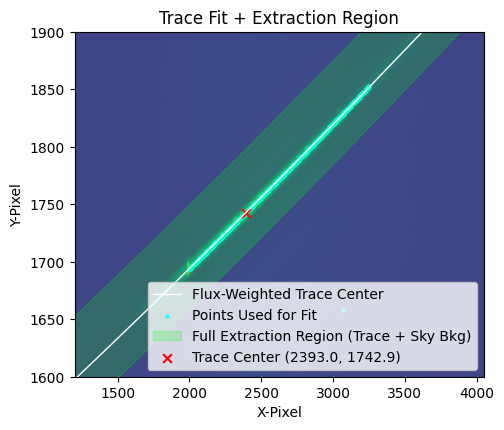

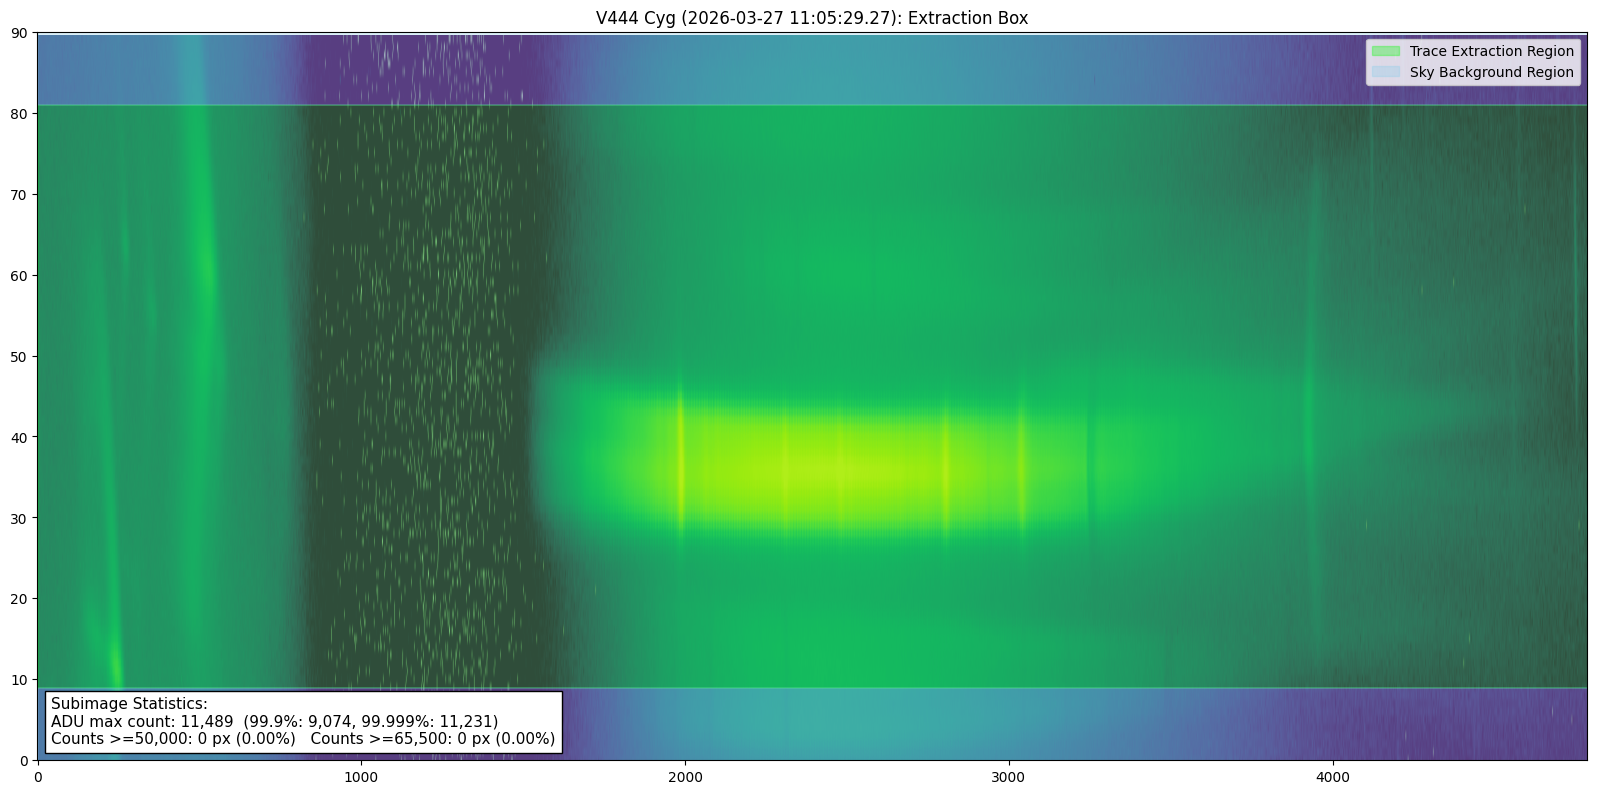

/Users/joshuamarine/Desktop/Code/grism_utils_v2.py:588: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


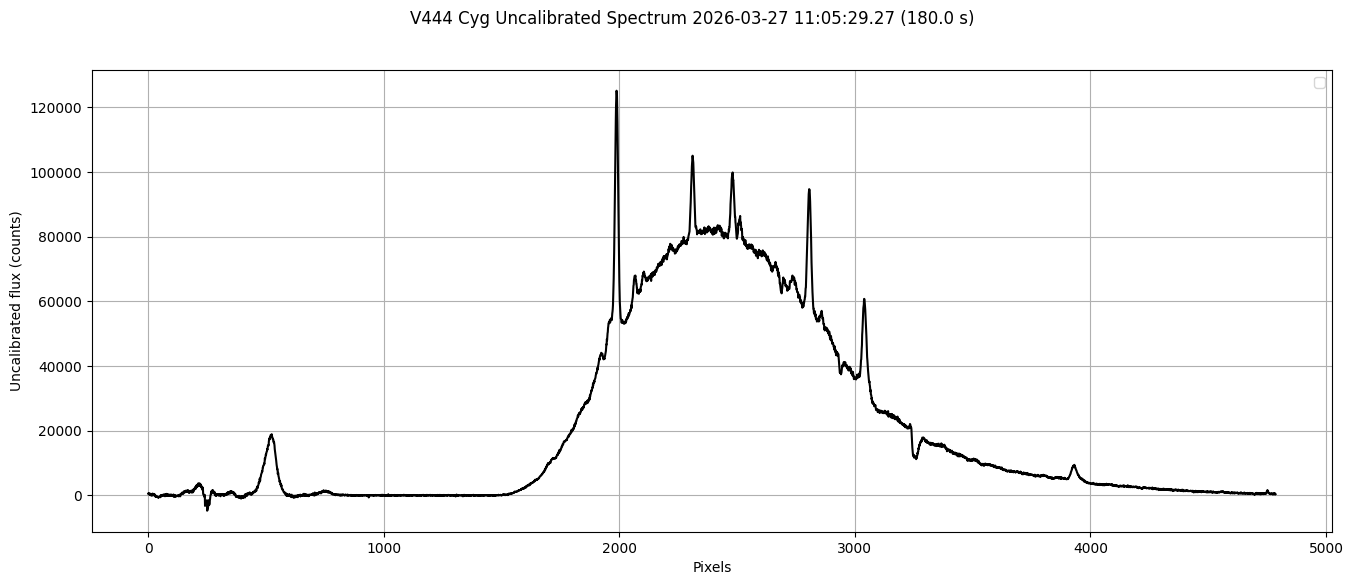

Recursion limit reached, unable to fit feature


AttributeError: 'spectrum' object has no attribute 'pixel_mask'

In [322]:
i = 0

calib_img = matches['science_matches'][i].get("averaged_calib_spectrum", None)
grism_image = matches['science_matches'][i]["science_file"]

S = spectrum(grism_image, calib_spectrum=calib_img, filter=filter)

# print(f'Moon Angle & Phase: {S.moonangle:.2f} degrees, {(S.moonphase * 100):.2f} %')

trace_center, cutouts, subim = S.fit_trace(plot = True, show_points = True,curved = True)
spec = S.extract_spectrum(show_box = True, plot = True, curved_box = True)
telluric_pixel = S.fit_telluric(plot = True, debugging = False)
# telluric_pixel = S.fit_telluric(x_guess = 2940, plot = True, debugging = False, manual_override = True)
# print(telluric_pixel)
waves = S.wavelength_calibrate(plot = False)
cal_spec = S.gain_calibrate(plot = True)
fig = S.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True)

# All Done!

Now let's output a pdf file of the results

In [310]:
# Wrap all class functions into parent function that can have input parameters of select indices for manual entry or things like that
# Have function output flagged spectra to rerun
# Run parent function in for loop for all targets to process all data
# Save final data as csv with column entries for telluric pixel entry 
# Create conditional to pull from existing csv or default if not csv
# Create manual entry conditional for if CSV already exists then do/don't overwrite
# Anytime you're reusing the same thing/attribute you want to possibly split that into different classes
  # This way if you make changes it propagates through fluidly
# For averaging, reinitialize spectrum class with only necessary attributes
# Initialize new class structure for output calibration parameters applied to science spectra

# Make sure all science spectra have calibration spectra assigned to them

# ffmpeg
# matplotlib funcanimation

In [311]:
# !!! Please paste in your last name here for saving output files !!!
username = 'Marine'


out_folder = os.getcwd() + '/calibrated_data/'
gdrive_out_folder = drive_path + '/calibrated_data/'

if os.path.exists(out_folder) and os.path.isdir(out_folder) and os.path.isdir(gdrive_out_folder):
    print("Directories exist, you're good to go!")
else:
    print("Directories do not exist, change your directories")

Directories exist, you're good to go!


## (Optional) Look at Final Spectra

In [312]:
# Show all the spectra again

for i in range(len(spectra)):
  spec = spectra[i]
  if spec.flagged:
    print(f'Skipping spectrum {i+1} of {len(spectra)}: {spec.grism_image} (Flagged)')
    continue
  print(f'Processing spectrum {i+1} of {len(spectra)}: {spec.grism_image}')
  print(f'Moon Angle & Phase: {spec.moonangle:.2f} degrees, {(spec.moonphase * 100):.2f} %')
  print(f'Telluric Line Pixel: {spec.telluric_pixel:.2f}')

  # fig = spec.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True)

Processing spectrum 1 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-03-27/jos_V444_Cyg_lrg_180s_2026-03-27T11-03-06_calibrated.fts.fz
Moon Angle & Phase: 117.79 degrees, 68.38 %
Telluric Line Pixel: 2940.00
Processing spectrum 2 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-03-27/jos_V444_Cyg_lrg_180s_2026-03-27T11-06-13_calibrated.fts.fz
Moon Angle & Phase: 117.81 degrees, 68.40 %
Telluric Line Pixel: 2940.00
Processing spectrum 3 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-09/jos_V444_Cyg_lrg_120s_2026-04-09T12-02-03_calibrated.fts.fz
Moon Angle & Phase: 69.73 degrees, 56.76 %
Telluric Line Pixel: 2940.00


## Save CSVs and PDFs Locally

In [313]:
from matplotlib.backends.backend_pdf import PdfPages

# Define the output PDF file
pdf_filename = out_folder + f"{username}_{targets[0]}_{filter}_calibrated_spectra.pdf"

# Check if the file exists and notify about overwriting
if os.path.exists(pdf_filename):
    print(f"The file '{pdf_filename}' already exists and will be overwritten.")

# Create a PDF object to store plots
with PdfPages(pdf_filename) as pdf:
    for i in range(len(spectra)):
        spec = spectra[i]
        print(f'Processing spectrum {i+1} of {len(spectra)}: {spec.grism_image}')

        if spec.flagged:
            continue

        fig = spec.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True, show = False)

        # Save the current figure to the PDF
        pdf.savefig(fig)
        plt.close()  # Close the plot to free memory

print(f"All plots saved to {pdf_filename}")

Processing spectrum 1 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-03-27/jos_V444_Cyg_lrg_180s_2026-03-27T11-03-06_calibrated.fts.fz
Processing spectrum 2 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-03-27/jos_V444_Cyg_lrg_180s_2026-03-27T11-06-13_calibrated.fts.fz
Processing spectrum 3 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-09/jos_V444_Cyg_lrg_120s_2026-04-09T12-02-03_calibrated.fts.fz
All plots saved to /Users/joshuamarine/Desktop/Code/calibrated_data/Marine_V444_Cyg_lrg_calibrated_spectra.pdf


In [314]:
# Write out CSV files
path = out_folder
folder_name = f'{targets[0]}_{filter}_calibrated_csvs'
output_dir = os.path.join(path, folder_name)

# --- Replace the whole folder if it already exists ---
if os.path.exists(output_dir):
    print(f"⚠️  Folder already exists — deleting and recreating: {output_dir}")
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

for i, spec in enumerate(spectra):
    
    if spec.flagged:
        continue
    # ----------------------------
    # Calibrated spectrum
    # ----------------------------
    waves = spec.waves
    flux  = spec.cal_spec

    dataframe = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux
    })

    img_name = img_files[i].split("/")[-1].replace(".fts.fz", ".csv")
    output_path = os.path.join(output_dir, f'{username}_{img_name}')

    if os.path.exists(output_path):
        print(f"Overwriting existing file: {output_path}")

    dataframe.to_csv(output_path, index=False)

    # ----------------------------
    # Normalized spectrum
    # ----------------------------
    if hasattr(spec, "cal_spec_norm"):
        flux_norm = spec.cal_spec_norm
    else:
        # fallback: normalize on the fly
        flux_norm = flux / np.median(flux)

    dataframe_norm = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux_norm
    })

    img_name_norm = img_files[i].split("/")[-1].replace(".fts.fz", "_norm.csv")
    output_path_norm = os.path.join(output_dir, f'{username}_{img_name_norm}')

    if os.path.exists(output_path_norm):
        print(f"Overwriting existing file: {output_path_norm}")

    dataframe_norm.to_csv(output_path_norm, index=False)

print(f"\nCSV files have been successfully written to {output_dir}")


CSV files have been successfully written to /Users/joshuamarine/Desktop/Code/calibrated_data/V444_Cyg_lrg_calibrated_csvs


## Save CSVs and PDFs to Google Drive (Mounted only)

In [315]:
gdrive_pdf_filename = gdrive_out_folder + f"{username}_{targets[0]}_calibrated_spectra.pdf"

# Check if the file exists and notify about overwriting
if os.path.exists(gdrive_pdf_filename):
    print(f"The file '{gdrive_pdf_filename}' already exists and will be overwritten.")

# Create a PDF object to store plots
with PdfPages(gdrive_pdf_filename) as pdf:
    for i in range(len(spectra)):
        spec = spectra[i]
        print(f'Processing spectrum {i+1} of {len(spectra)}: {spec.grism_image}')

        if spec.flagged:
            continue

        fig = spec.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True, show = False)

        # Save the current figure to the PDF
        pdf.savefig(fig)
        plt.close()  # Close the plot to free memory

print(f"All plots saved to {gdrive_pdf_filename}")


Processing spectrum 1 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-03-27/jos_V444_Cyg_lrg_180s_2026-03-27T11-03-06_calibrated.fts.fz
Processing spectrum 2 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-03-27/jos_V444_Cyg_lrg_180s_2026-03-27T11-06-13_calibrated.fts.fz
Processing spectrum 3 of 3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-09/jos_V444_Cyg_lrg_120s_2026-04-09T12-02-03_calibrated.fts.fz
All plots saved to /Users/joshuamarine/gdrive/Shared Drives/MACRO-Be/resources/Data/calibrated_data/Marine_V444_Cyg_calibrated_spectra.pdf


In [316]:
# Write out CSV files to google drive
path = out_folder
folder_name = f'{targets[0]}_{filter}_calibrated_csvs'
output_dir = os.path.join(gdrive_out_folder, folder_name)

# --- Replace the whole folder if it already exists ---
if os.path.exists(output_dir):
    print(f"⚠️  Folder already exists — deleting and recreating: {output_dir}")
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

for i, spec in enumerate(spectra):

    if spec.flagged:
        continue
    # ----------------------------
    # Calibrated spectrum
    # ----------------------------
    waves = spec.waves
    flux  = spec.cal_spec

    dataframe = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux
    })

    img_name = img_files[i].split("/")[-1].replace(".fts.fz", ".csv")
    output_path = os.path.join(output_dir, f'{username}_{img_name}')

    if os.path.exists(output_path):
        print(f"Overwriting existing file: {output_path}")

    dataframe.to_csv(output_path, index=False)

    # ----------------------------
    # Normalized spectrum
    # ----------------------------
    if hasattr(spec, "cal_spec_norm"):
        flux_norm = spec.cal_spec_norm
    else:
        # fallback: normalize on the fly
        flux_norm = flux / np.median(flux)

    dataframe_norm = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux_norm
    })

    img_name_norm = img_files[i].split("/")[-1].replace(".fts.fz", "_norm.csv")
    output_path_norm = os.path.join(output_dir, f'{username}_{img_name_norm}')

    if os.path.exists(output_path_norm):
        print(f"Overwriting existing file: {output_path_norm}")

    dataframe_norm.to_csv(output_path_norm, index=False)

print(f"\nCSV files have been successfully written to {output_dir}")


CSV files have been successfully written to /Users/joshuamarine/gdrive/Shared Drives/MACRO-Be/resources/Data/calibrated_data/V444_Cyg_lrg_calibrated_csvs
